In [6]:
# ==========================================
# CELL 1: DATA INSPECTION & PREPROCESSING
# ==========================================
import pandas as pd

# 1. Load the raw dataset
# Make sure you have uploaded 'nvda_stock_data_raw_nasdaq.csv' to your Colab environment!
file_path = 'nvda_stock_data_raw_nasdaq.csv'
df = pd.read_csv(file_path)

print("--- RAW DATA INSPECTION ---")
print("Notice how 'close', 'volume', etc. are read as 'object' (strings) instead of numbers:")
print(df.info())
print("\nFirst 3 rows of raw data:")
display(df.head(3)) # 'display()' looks much nicer in Colab than 'print()'

# 2. Data Cleaning
print("\n--- CLEANING DATA ---")
# A. Clean the price columns: remove '$' and ',' then convert to float
price_columns = ['close', 'open', 'high', 'low']
for col in price_columns:
    df[col] = df[col].replace(r'[\$,]', '', regex=True).astype(float)

# B. Clean the volume column: remove ',' and convert to integer
df['volume'] = df['volume'].replace(r',', '', regex=True).astype(int)

# C. Convert 'date' to actual Datetime objects
df['date'] = pd.to_datetime(df['date'])

# D. Sort chronologically (oldest to newest) - CRITICAL for time series!
df = df.sort_values('date').reset_index(drop=True)

# E. Handle missing values
missing_count = df.isnull

--- RAW DATA INSPECTION ---
Notice how 'close', 'volume', etc. are read as 'object' (strings) instead of numbers:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2514 entries, 0 to 2513
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    2514 non-null   object
 1   close   2514 non-null   object
 2   volume  2514 non-null   object
 3   open    2514 non-null   object
 4   high    2514 non-null   object
 5   low     2514 non-null   object
dtypes: object(6)
memory usage: 118.0+ KB
None

First 3 rows of raw data:


,date,close,volume,open,high,low
0,03/17/2026,$181.93,"182,497,800",$185.06,$185.40,$181.6804
1,03/16/2026,$183.22,"217,307,400",$182.97,$188.88,$181.41
2,03/13/2026,$180.25,"160,988,400",$184.92,$186.09,$179.94



--- CLEANING DATA ---


--- FEATURE ENGINEERING ---
Engineered Features Added: SMA_10, SMA_50, Daily_Return, Volatility_10d


,date,close,SMA_10,Daily_Return,Volatility_10d
2460,2026-03-11,186.03,182.226,0.006819,0.029198
2461,2026-03-12,183.14,182.051,-0.015535,0.023906
2462,2026-03-13,180.25,182.357,-0.015780,0.020075
2463,2026-03-16,183.22,182.431,0.016477,0.018379
2464,2026-03-17,181.93,182.619,-0.007041,0.017955



--- EXPLORATORY DATA ANALYSIS (VISUALIZATIONS) ---


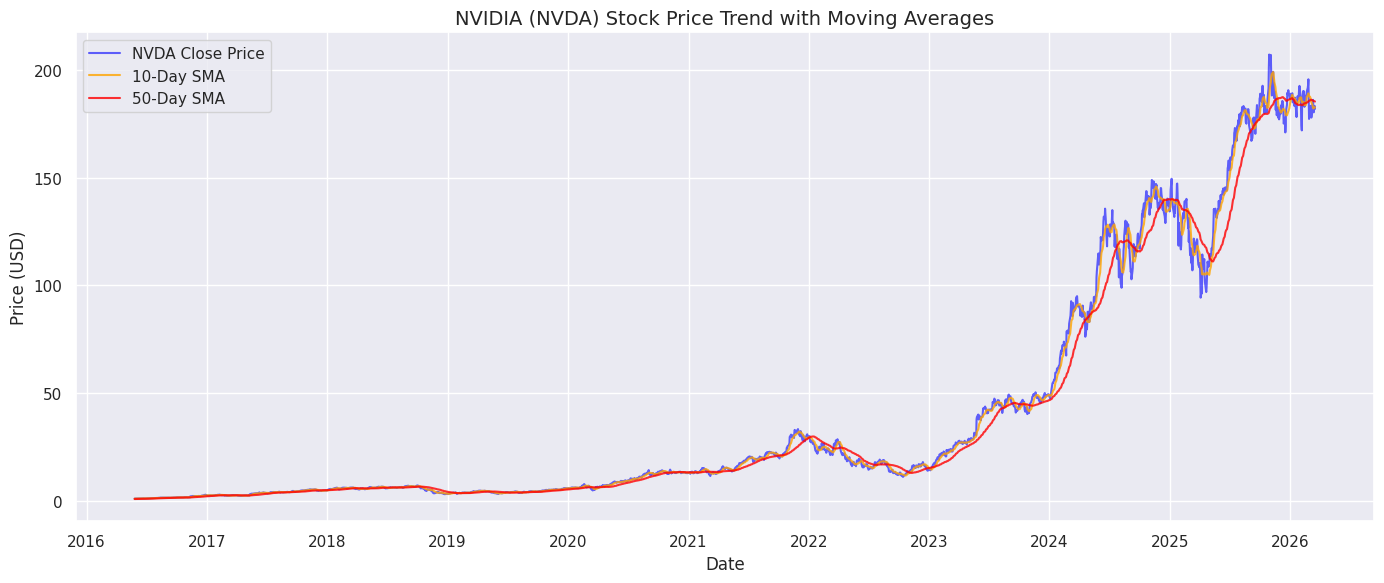

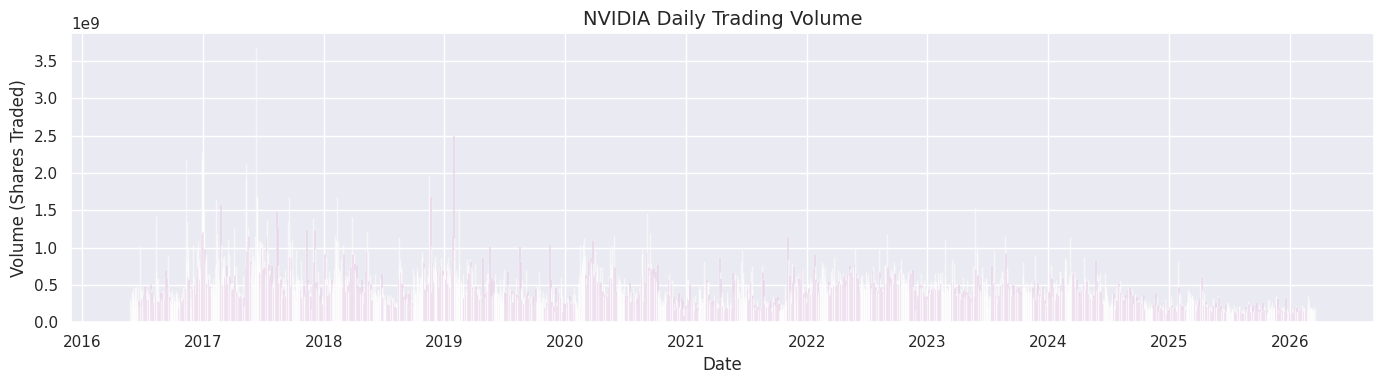

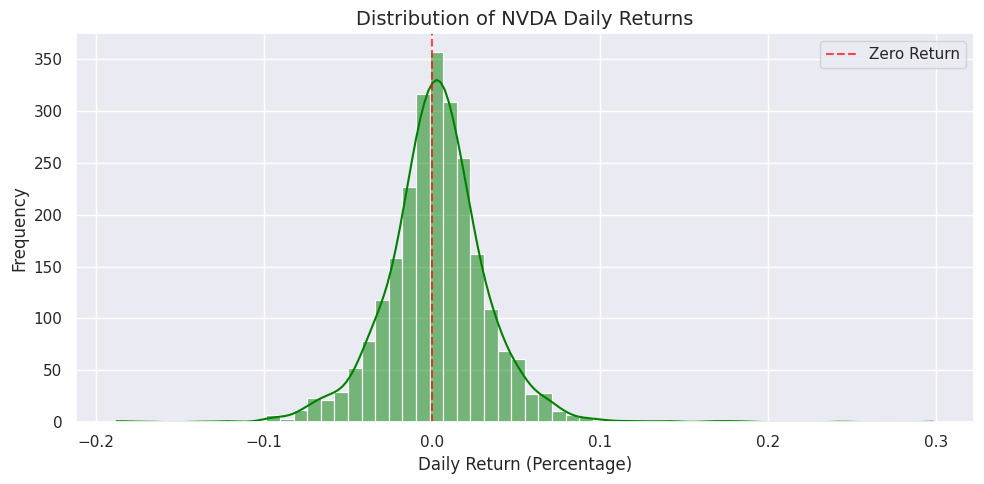

In [7]:
# ==========================================
# CELL 2: FEATURE ENGINEERING & EDA
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("--- FEATURE ENGINEERING ---")
# Create a copy of the dataframe to avoid warnings
eda_df = df.copy()

# 1. Simple Moving Averages (Trend Indicators)
eda_df['SMA_10'] = eda_df['close'].rolling(window=10).mean()
eda_df['SMA_50'] = eda_df['close'].rolling(window=50).mean()

# 2. Daily Returns (Momentum Indicator)
eda_df['Daily_Return'] = eda_df['close'].pct_change()

# 3. Volatility (Risk Indicator: 10-day rolling standard deviation of returns)
eda_df['Volatility_10d'] = eda_df['Daily_Return'].rolling(window=10).std()

# Drop the initial rows that now have NaN values because of the rolling windows
eda_df = eda_df.dropna().reset_index(drop=True)

print("Engineered Features Added: SMA_10, SMA_50, Daily_Return, Volatility_10d")
display(eda_df[['date', 'close', 'SMA_10', 'Daily_Return', 'Volatility_10d']].tail())


print("\n--- EXPLORATORY DATA ANALYSIS (VISUALIZATIONS) ---")
# Set a nice theme for the plots
sns.set_theme(style="darkgrid")

# Plot 1: Closing Price and Moving Averages
plt.figure(figsize=(14, 6))
plt.plot(eda_df['date'], eda_df['close'], label='NVDA Close Price', color='blue', alpha=0.6)
plt.plot(eda_df['date'], eda_df['SMA_10'], label='10-Day SMA', color='orange', alpha=0.8)
plt.plot(eda_df['date'], eda_df['SMA_50'], label='50-Day SMA', color='red', alpha=0.8)
plt.title('NVIDIA (NVDA) Stock Price Trend with Moving Averages', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: Trading Volume Over Time
plt.figure(figsize=(14, 4))
plt.bar(eda_df['date'], eda_df['volume'], color='purple', alpha=0.6)
plt.title('NVIDIA Daily Trading Volume', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Volume (Shares Traded)', fontsize=12)
plt.tight_layout()
plt.show()

# Plot 3: Distribution of Daily Returns
plt.figure(figsize=(10, 5))
sns.histplot(eda_df['Daily_Return'], bins=60, kde=True, color='green')
plt.title('Distribution of NVDA Daily Returns', fontsize=14)
plt.xlabel('Daily Return (Percentage)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
# Adding a vertical line at 0 for reference
plt.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Zero Return')
plt.legend()
plt.tight_layout()
plt.show()

# (Save these generated plots to use in your PowerPoint presentation!)

--- 1. PREPARING DATA FOR MACHINE LEARNING ---
Training Data: 1971 days
Testing Data: 493 days

--- 2. MODEL TRAINING ---
Model training complete!

--- 3. MODEL EVALUATION ---
Model Accuracy: 48.48%

Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.45      0.53      0.49       230
      Up (1)       0.52      0.45      0.48       263

    accuracy                           0.48       493
   macro avg       0.49      0.49      0.48       493
weighted avg       0.49      0.48      0.48       493


--- 4. VISUALIZING RESULTS ---


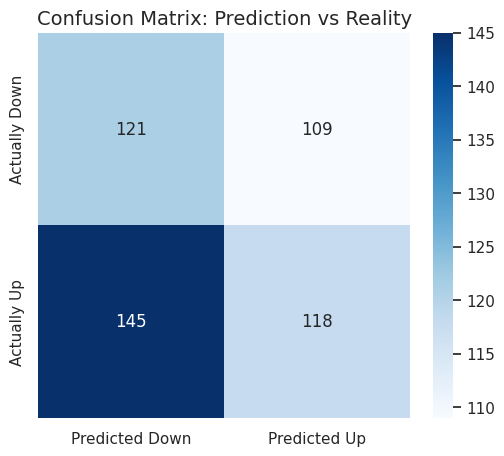

/tmp/ipykernel_3892/3334166444.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=features, palette='viridis')


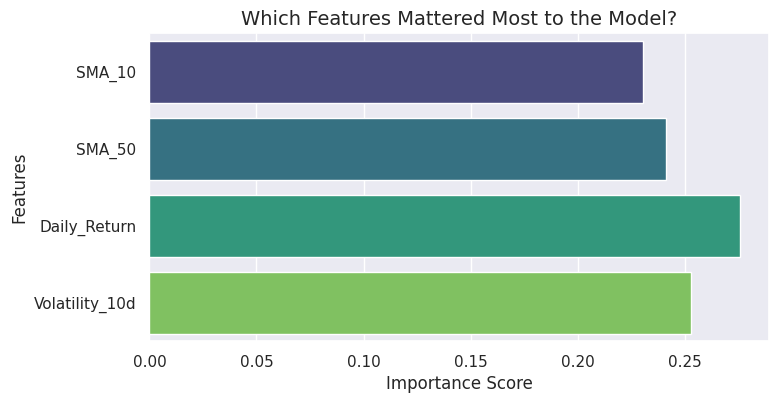

In [8]:
# ==========================================
# CELL 3: MACHINE LEARNING MODELING
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("--- 1. PREPARING DATA FOR MACHINE LEARNING ---")

# We will use the 'eda_df' from Cell 2.
ml_df = eda_df.copy()

# A. Create the Target Variable (What we want to predict)
# We want to predict if TOMORROW'S closing price is higher than TODAY'S.
# Shift(-1) grabs the next day's price.
ml_df['Next_Day_Close'] = ml_df['close'].shift(-1)

# Target = 1 if the price went UP tomorrow, Target = 0 if it went DOWN or stayed flat
ml_df['Target'] = (ml_df['Next_Day_Close'] > ml_df['close']).astype(int)

# Drop the last row because we don't have a "tomorrow" for the very last day in the dataset
ml_df = ml_df.dropna().reset_index(drop=True)

# B. Select our Features (X) and Target (y)
# We are using the features we engineered in Cell 2!
features = ['SMA_10', 'SMA_50', 'Daily_Return', 'Volatility_10d']
X = ml_df[features]
y = ml_df['Target']

# C. Train-Test Split (Time Series specific!)
# CRITICAL: We cannot shuffle time-series data. We must train on the PAST to predict the FUTURE.
# We will use the first 80% of data to train, and the last 20% to test.
split_index = int(len(ml_df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Training Data: {len(X_train)} days")
print(f"Testing Data: {len(X_test)} days")

print("\n--- 2. MODEL TRAINING ---")
# Initialize a Random Forest Classifier
# random_state ensures we get the exact same results every time we run the cell
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# Train the model on the training data
rf_model.fit(X_train, y_train)
print("Model training complete!")

print("\n--- 3. MODEL EVALUATION ---")
# Make predictions on the testing data (the "future" data the model hasn't seen yet)
predictions = rf_model.predict(X_test)

# Calculate Accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

# Detailed Classification Report
print("Classification Report:")
print(classification_report(y_test, predictions, target_names=['Down (0)', 'Up (1)']))

print("\n--- 4. VISUALIZING RESULTS ---")
# Plot 1: Confusion Matrix
# This shows us exactly where the model got it right and where it got it wrong.
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Down', 'Predicted Up'],
            yticklabels=['Actually Down', 'Actually Up'])
plt.title('Confusion Matrix: Prediction vs Reality', fontsize=14)
plt.show()

# Plot 2: Feature Importance
# This tells us which engineered feature helped the model the most!
importances = rf_model.feature_importances_
plt.figure(figsize=(8, 4))
sns.barplot(x=importances, y=features, palette='viridis')
plt.title('Which Features Mattered Most to the Model?', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# (Take screenshots of the Accuracy, Classification Report, and these two plots for your presentation!)

In [ ]:
# ==========================================
# CELL 4: INTERACTIVE SYSTEM & LIVE PREDICTION
# ==========================================
import time

# 1. Define Functions for our System (Demonstrating 'Functions' rubric requirement)
def predict_tomorrow():
    """Uses the trained model to predict tomorrow's stock movement based on today's data."""
    print("\n--- INITIATING LIVE PREDICTION ---")
    time.sleep(1) # Adds a slight delay for a "processing" effect

    # Get the very last row of our feature dataset (the most recent day)
    latest_data = X.iloc[-1:]
    latest_date = eda_df['date'].iloc[-1].strftime('%Y-%m-%d')
    latest_close = eda_df['close'].iloc[-1]

    print(f"Fetching latest market data for {latest_date}...")
    print(f"Latest Closing Price: ${latest_close:.2f}")
    print(f"Current 10-Day SMA: ${latest_data['SMA_10'].values[0]:.2f}")

    # Make the prediction
    prediction = rf_model.predict(latest_data)

    print("\n[ PREDICTION RESULT ]")
    if prediction[0] == 1:
        print("📈 The model predicts the stock will go UP tomorrow.")
    else:
        print("📉 The model predicts the stock will go DOWN tomorrow.")
    print("----------------------------------\n")

def show_system_status():
    """Displays current system data and model accuracy."""
    print("\n--- SYSTEM STATUS ---")
    print(f"Total Trading Days Processed: {len(eda_df)}")
    print(f"Model Accuracy on Test Data: {accuracy * 100:.2f}%")
    print(f"Algorithm: Random Forest Classifier (Depth: 5, Trees: 100)")
    print("----------------------------------\n")

# 2. Main Interactive Loop (Demonstrating 'Control Loops' & 'Exception Handling')
def main_menu():
    print("="*40)
    print(" WELCOME TO THE NVDA PREDICTION SYSTEM ")
    print("="*40)

    while True:
        print("\nPlease select an option:")
        print("1. Predict Tomorrow's Trend")
        print("2. View System & Model Status")
        print("3. Exit System")

        user_input = input("Enter your choice (1/2/3): ")

        # Exception Handling: Making sure the system doesn't crash if they type a word instead of a number
        try:
            choice = int(user_input)

            if choice == 1:
                predict_tomorrow()
            elif choice == 2:
                show_system_status()
            elif choice == 3:
                print("\nExiting system... Thank you for using the NVDA Predictor!")
                break # Breaks the control loop
            else:
                print("\n[!] Invalid selection. Please choose 1, 2, or 3.")

        except ValueError:
            print("\n[!] Error: Please enter a valid number, not text.")

# 3. Execute the Menu
# (In Google Colab, this will open a little text box below the cell for you to type in!)
main_menu()

 WELCOME TO THE NVDA PREDICTION SYSTEM 

Please select an option:
1. Predict Tomorrow's Trend
2. View System & Model Status
3. Exit System
